# Reservoir Computing Workbench
Run forecasts with `run_reservoir_forecast.py`, evaluate with `eval_forecast.py`, and plot with `plot_forecast.py`. Edit the parameters below to choose the system and reservoir settings, then run the cells in order.

In [13]:
# Setup imports and path
from pathlib import Path
import sys, json
import numpy as np

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import run_reservoir_forecast as rcf
import eval_forecast as ef
import plot_forecast as pf
print('Repo root:', repo_root)

Repo root: /Users/krithikesh/Documents/CU/Juan-research/Github public/reservoir-computing


## Parameters
Edit these to choose system, tweak system and reservoir settings, and control training/forecast durations.

In [14]:
# Select system and parameters
system_name = 'sprott-linz'  # 'sprott-linz' or 'lorenz'
# For sprott-linz use {'a': 0.42}; for lorenz use {'sigma': 10.0, 'rho': 28.0, 'beta': 8.0/3.0}
system_params = {'a': 0.40}  # e.g., {'rho': 30.0} for lorenz or {'a': 0.41} for sprott-linz

# Simulation times
training_time = 60.0   # seconds
forecast_time = 30.0    # seconds
dt = 0.001            # time step

# Reservoir hyperparameters
reservoir_size = 500
spectral_radius = 1.2
density = 6.0
input_scale = 0.1
bias = 1.0
lam = 1e-4
washout = 800

# Integrators
training_integrator = 'rk4'  # 'euler' or 'rk4'
truth_integrator = 'rk4'     # 'euler' or 'rk4'

# Misc
seed = 123

cfg = rcf.Config(
    system_name=system_name,
    system_params=system_params,
    training_time=training_time,
    dt=dt,
    reservoir_size=reservoir_size,
    spectral_radius=spectral_radius,
    density=density,
    input_scale=input_scale,
    bias=bias,
    lam=lam,
    washout=washout,
    truth_integrator=truth_integrator,
    training_integrator=training_integrator,
    forecast_time=forecast_time,
    seed=seed,
)
cfg

Config(system_name='sprott-linz', system_params={'a': 0.4}, training_time=60.0, dt=0.001, reservoir_size=500, spectral_radius=1.2, density=6.0, input_scale=0.1, bias=1.0, lam=0.0001, washout=800, truth_integrator='rk4', training_integrator='rk4', forecast_time=30.0, seed=123)

## Run a forecast
Trains the reservoir and produces true vs predicted trajectories.

In [15]:
results = rcf.run(cfg)
forecast = results['forecast']
print('true shape:', forecast['true'].shape, 'pred shape:', forecast['pred'].shape, 'times shape:', forecast['times'].shape)

true shape: (3, 30000) pred shape: (3, 30000) times shape: (30000,)


## Evaluate errors

In [16]:
errs = ef.evaluate_forecast_results(forecast, verbose=True)
errs

MSE dim: [0.00244668 0.00378249 0.00197806]
NRMSE dim: [0.06395954 0.07609756 0.08150177]
Total MSE: 0.0027357427978407668
Total NRMSE: 0.058947754726693564
Trajectory distance: 0.03981571852622192
Divergence threshold: 0.041377144758245055
Divergence time: 5.070169005633521


{'mse_dim': array([0.00244668, 0.00378249, 0.00197806]),
 'nrmse_dim': array([0.06395954, 0.07609756, 0.08150177]),
 'mse_total': 0.0027357427978407668,
 'nrmse_total': 0.058947754726693564,
 'trajectory_distance': 0.03981571852622192,
 'divergence_time': 5.070169005633521,
 'divergence_threshold': 0.041377144758245055}

## Plot forecast and error

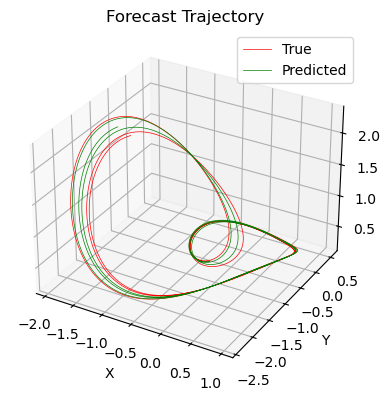

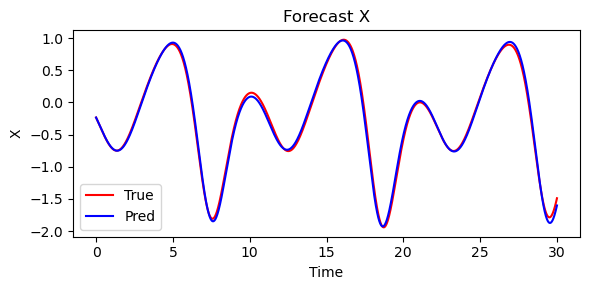

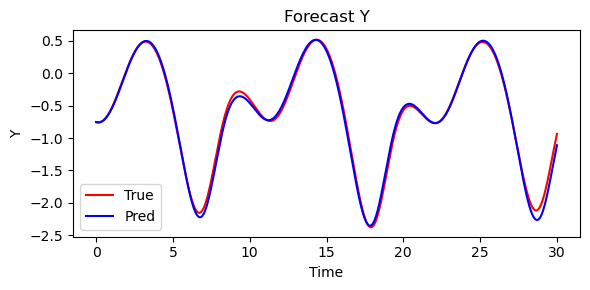

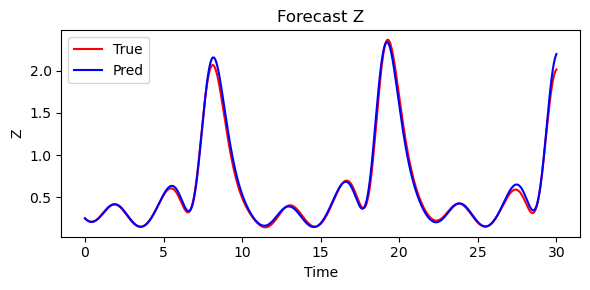

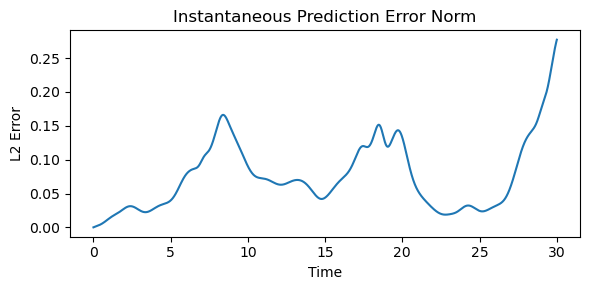

In [17]:
_ = pf.plot_all(forecast, from_time=0.0, to_time=min(30.0, float(forecast['times'][-1])), error_plot=True)

## Save and reload
Save arrays to disk and reload to evaluate/plot without retraining.

In [ ]:
from pathlib import Path
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / 'workbench_test'
rcf.save_results(str(base), results)
print('Saved to:', str(base)+'.npz', 'and', str(base)+'.json')
npz = np.load(str(base)+'.npz')
forecast_loaded = {'true': npz['true'], 'pred': npz['pred'], 'times': npz['times']}
errs_loaded = ef.evaluate_forecast_results(forecast_loaded, verbose=True)
_ = pf.plot_all(forecast_loaded, from_time=0.0, to_time=min(5.0, float(forecast_loaded['times'][-1])), error_plot=True)

## Alternate system example (Lorenz)

In [ ]:
cfg2 = rcf.Config(system_name='lorenz', forecast_time=6.0, training_time=80.0, dt=0.002, seed=7, reservoir_size=400)
results2 = rcf.run(cfg2)
fc2 = results2['forecast']
_ = ef.evaluate_forecast_results(fc2, verbose=True)
_ = pf.plot_all(fc2, from_time=0.0, to_time=min(4.0, float(fc2['times'][-1])), error_plot=True)

## Parameter sweep: Sprott–Linz parameter 'a'
We’ll sweep the Sprott–Linz parameter a from 0.05 to 0.45 in steps of 0.05. For each a value, we’ll run multiple forecasts (controlled by num_runs_per_a), log progress, compute trajectory distance and divergence time per run, and then record the average across the runs. Finally, we’ll plot average trajectory distance vs a and average divergence time vs a.

In [26]:
# Sweep 'a' from 0.05 to 0.45 (step 0.05), five runs per 'a' and log progress
import numpy as np
from time import time

# Ensure required modules are available from earlier cells
# rcf: run_reservoir_forecast, ef: eval_forecast

a_values = np.round(np.arange(0.10, 0.75 + 1e-9, 0.05), 2)
num_runs_per_a = 3

# Reuse parameters from above if available; otherwise provide sensible fallbacks
try:
    training_time
except NameError:
    training_time = 60.0
try:
    forecast_time
except NameError:
    forecast_time = 30.0
try:
    dt
except NameError:
    dt = 0.001
try:
    reservoir_size
except NameError:
    reservoir_size = 500
try:
    spectral_radius
except NameError:
    spectral_radius = 1.1
try:
    density
except NameError:
    density = 6.0
try:
    input_scale
except NameError:
    input_scale = 0.1
try:
    bias
except NameError:
    bias = 1.0
try:
    lam
except NameError:
    lam = 1e-4
try:
    washout
except NameError:
    washout = 800
try:
    training_integrator
except NameError:
    training_integrator = 'rk4'
try:
    truth_integrator
except NameError:
    truth_integrator = 'rk4'
try:
    seed
except NameError:
    seed = 42

avg_traj_distance = []
avg_divergence_time = []
sweep_logs = []  # store per-a, per-run metrics

start_all = time()
print(f"Starting sweep over {len(a_values)} 'a' values with {num_runs_per_a} runs each...")

for idx, a_val in enumerate(a_values, start=1):
    run_traj = []
    run_divt = []
    t0 = time()
    print(f"[{idx}/{len(a_values)}] a={a_val:.2f} -> running {num_runs_per_a} runs...")

    for k in range(num_runs_per_a):
        # Vary the seed per run to change initial conditions/reservoir sampling deterministically
        this_seed = int(seed + 1000*idx + k)
        cfg_sweep = rcf.Config(
            system_name='sprott-linz',
            system_params={'a': float(a_val)},
            training_time=training_time,
            dt=dt,
            reservoir_size=reservoir_size,
            spectral_radius=spectral_radius,
            density=density,
            input_scale=input_scale,
            bias=bias,
            lam=lam,
            washout=washout,
            truth_integrator=truth_integrator,
            training_integrator=training_integrator,
            forecast_time=forecast_time,
            seed=this_seed,
        )
        out = rcf.run(cfg_sweep)
        fc = out['forecast']
        # Use 3000 samples when computing trajectory distance
        errs = ef.compute_errors(fc['true'], fc['pred'], times=fc.get('times'), traj_samples=3000, seed=this_seed)

        # Collect metrics for this run
        traj_d = float(errs.get('trajectory_distance', np.nan))
        div_t = errs.get('divergence_time', None)
        div_t = float('nan') if div_t is None else float(div_t)
        run_traj.append(traj_d)
        run_divt.append(div_t)

        # Lightweight progress per run
        if (k + 1) % 1 == 0:
            print(f"    run {k+1}/{num_runs_per_a}: traj_dist={traj_d:.6f}, divergence_time={div_t:.6f}")

    # Average across runs (ignore NaNs for divergence time)
    avg_td = float(np.mean(run_traj)) if len(run_traj) else float('nan')
    avg_dt = float(np.nanmean(run_divt)) if len(run_divt) else float('nan')
    avg_traj_distance.append(avg_td)
    avg_divergence_time.append(avg_dt)
    sweep_logs.append({
        'a': float(a_val),
        'traj_dists': [float(x) for x in run_traj],
        'div_times': [None if np.isnan(x) else float(x) for x in run_divt],
        'avg_traj_distance': avg_td,
        'avg_divergence_time': None if np.isnan(avg_dt) else float(avg_dt),
    })

    dt_s = time() - t0
    print(f"    -> a={a_val:.2f} avg: traj_dist={avg_td:.6f}, divergence_time={avg_dt:.6f}  (elapsed {dt_s:.1f}s)")

total_s = time() - start_all
print(f"Sweep complete in {total_s/60.0:.1f} min.")

# Bundle results for later use
sweep_summary = {
    'a_values': a_values.copy(),
    'avg_traj_distance': np.array(avg_traj_distance, dtype=float),
    'avg_divergence_time': np.array(avg_divergence_time, dtype=float),
    'logs': sweep_logs,
}
sweep_summary

Starting sweep over 14 'a' values with 3 runs each...
[1/14] a=0.10 -> running 3 runs...
    run 1/3: traj_dist=0.004430, divergence_time=25.319844
    run 1/3: traj_dist=0.004430, divergence_time=25.319844
    run 2/3: traj_dist=0.045179, divergence_time=11.803393
    run 2/3: traj_dist=0.045179, divergence_time=11.803393
    run 3/3: traj_dist=0.016728, divergence_time=1.910064
    -> a=0.10 avg: traj_dist=0.022112, divergence_time=13.011100  (elapsed 8.6s)
[2/14] a=0.15 -> running 3 runs...
    run 3/3: traj_dist=0.016728, divergence_time=1.910064
    -> a=0.10 avg: traj_dist=0.022112, divergence_time=13.011100  (elapsed 8.6s)
[2/14] a=0.15 -> running 3 runs...
    run 1/3: traj_dist=0.008847, divergence_time=16.632554
    run 1/3: traj_dist=0.008847, divergence_time=16.632554
    run 2/3: traj_dist=0.002586, divergence_time=nan
    run 2/3: traj_dist=0.002586, divergence_time=nan
    run 3/3: traj_dist=0.003838, divergence_time=29.389980
    -> a=0.15 avg: traj_dist=0.005090, diver

/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42821/1317198296.py:116: RuntimeWarning: Mean of empty slice
  avg_dt = float(np.nanmean(run_divt)) if len(run_divt) else float('nan')


    run 1/3: traj_dist=nan, divergence_time=nan
    run 2/3: traj_dist=nan, divergence_time=nan
    run 2/3: traj_dist=nan, divergence_time=nan
    run 3/3: traj_dist=nan, divergence_time=nan
    -> a=0.70 avg: traj_dist=nan, divergence_time=nan  (elapsed 8.2s)
[14/14] a=0.75 -> running 3 runs...
    run 3/3: traj_dist=nan, divergence_time=nan
    -> a=0.70 avg: traj_dist=nan, divergence_time=nan  (elapsed 8.2s)
[14/14] a=0.75 -> running 3 runs...
    run 1/3: traj_dist=nan, divergence_time=nan
    run 1/3: traj_dist=nan, divergence_time=nan
    run 2/3: traj_dist=nan, divergence_time=nan
    run 2/3: traj_dist=nan, divergence_time=nan
    run 3/3: traj_dist=nan, divergence_time=nan
    -> a=0.75 avg: traj_dist=nan, divergence_time=nan  (elapsed 8.3s)
Sweep complete in 1.9 min.
    run 3/3: traj_dist=nan, divergence_time=nan
    -> a=0.75 avg: traj_dist=nan, divergence_time=nan  (elapsed 8.3s)
Sweep complete in 1.9 min.


{'a_values': array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
        0.65, 0.7 , 0.75]),
 'avg_traj_distance': array([0.02211231, 0.00509019, 0.0052651 , 0.00956681, 0.03059548,
        0.02188684, 0.06190382, 0.18365177,        nan,        nan,
               nan,        nan,        nan,        nan]),
 'avg_divergence_time': array([1.30111004e+01, 2.30112670e+01, 1.62310410e+01, 1.09828661e+01,
        1.01368379e+01, 9.09596987e+00, 1.26787560e+01, 4.51681723e+00,
        4.97283243e+00, 1.00003333e-03, 1.00003333e-03,            nan,
                   nan,            nan]),
 'logs': [{'a': 0.1,
   'traj_dists': [0.0044297647742686744,
    0.04517949922383573,
    0.01672765466952023],
   'div_times': [25.319843994799825, 11.803393446448215, 1.9100636687889596],
   'avg_traj_distance': 0.022112306222541542,
   'avg_divergence_time': 13.01110037001233},
  {'a': 0.15,
   'traj_dists': [0.008846647483765424,
    0.0025863240062147194,
    0.003837592810820377],

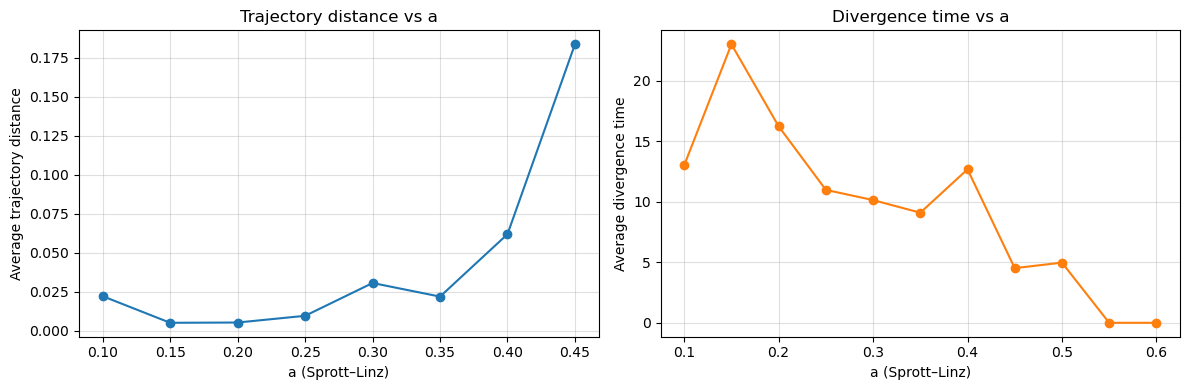

In [27]:
# Plot average trajectory distance vs 'a' and average divergence time vs 'a'
import matplotlib.pyplot as plt

avs = np.array(sweep_summary['a_values'], dtype=float)
avg_td = np.array(sweep_summary['avg_traj_distance'], dtype=float)
avg_dt = np.array(sweep_summary['avg_divergence_time'], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(avs, avg_td, marker='o')
axes[0].set_xlabel("a (Sprott–Linz)")
axes[0].set_ylabel("Average trajectory distance")
axes[0].set_title("Trajectory distance vs a")
axes[0].grid(True, alpha=0.4)

axes[1].plot(avs, avg_dt, marker='o', color='tab:orange')
axes[1].set_xlabel("a (Sprott–Linz)")
axes[1].set_ylabel("Average divergence time")
axes[1].set_title("Divergence time vs a")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Parameter sweep: Lorenz parameter 'rho'
We’ll sweep the Lorenz parameter rho from 20 to 40 in steps of 1. For each rho value, we’ll run multiple forecasts (controlled by num_runs_per_a if set, otherwise a local default), log progress, compute trajectory distance (with 3000 samples) and divergence time per run, and then record the average across the runs.

In [32]:
# Sweep 'rho' from 20 to 40 (step 1), runs per rho similar to Sprott–Linz sweep and log progress
import numpy as np
from time import time

# Use same run count if defined above, else default to 3
try:
    num_runs_per_a
    num_runs_per_rho = int(num_runs_per_a)
except NameError:
    num_runs_per_rho = 3

rho_values = np.arange(25, 41, 1, dtype=float)

# Reuse parameters from above if available; otherwise provide sensible fallbacks
try:
    training_time
except NameError:
    training_time = 200.0
try:
    forecast_time
except NameError:
    forecast_time = 10.0
try:
    dt
except NameError:
    dt = 0.001
try:
    reservoir_size
except NameError:
    reservoir_size = 500
try:
    spectral_radius
except NameError:
    spectral_radius = 1.2
try:
    density
except NameError:
    density = 6.0
try:
    input_scale
except NameError:
    input_scale = 0.1
try:
    bias
except NameError:
    bias = 1.0
try:
    lam
except NameError:
    lam = 1e-4
try:
    washout
except NameError:
    washout = 800
try:
    training_integrator
except NameError:
    training_integrator = 'rk4'
try:
    truth_integrator
except NameError:
    truth_integrator = 'rk4'
try:
    seed
except NameError:
    seed = 42

avg_traj_distance_rho = []
avg_divergence_time_rho = []
sweep_logs_rho = []

start_all = time()
print(f"Starting Lorenz rho sweep over {len(rho_values)} values with {num_runs_per_rho} runs each...")

for idx, rho_val in enumerate(rho_values, start=1):
    run_traj = []
    run_divt = []
    t0 = time()
    print(f"[{idx}/{len(rho_values)}] rho={rho_val:.0f} -> running {num_runs_per_rho} runs...")

    for k in range(num_runs_per_rho):
        this_seed = int(seed + 2000*idx + k)
        cfg_sweep = rcf.Config(
            system_name='lorenz',
            system_params={'sigma': 10.0, 'rho': float(rho_val), 'beta': 8.0/3.0},
            training_time=training_time,
            dt=dt,
            reservoir_size=reservoir_size,
            spectral_radius=spectral_radius,
            density=density,
            input_scale=input_scale,
            bias=bias,
            lam=lam,
            washout=washout,
            truth_integrator=truth_integrator,
            training_integrator=training_integrator,
            forecast_time=forecast_time,
            seed=this_seed,
        )
        out = rcf.run(cfg_sweep)
        fc = out['forecast']
        errs = ef.compute_errors(fc['true'], fc['pred'], times=fc.get('times'), traj_samples=10000, seed=this_seed)

        traj_d = float(errs.get('trajectory_distance', np.nan))
        div_t = errs.get('divergence_time', None)
        div_t = float('nan') if div_t is None else float(div_t)
        run_traj.append(traj_d)
        run_divt.append(div_t)

        print(f"    run {k+1}/{num_runs_per_rho}: traj_dist={traj_d:.6f}, divergence_time={div_t:.6f}")

    avg_td = float(np.mean(run_traj)) if len(run_traj) else float('nan')
    avg_dt = float(np.nanmean(run_divt)) if len(run_divt) else float('nan')
    avg_traj_distance_rho.append(avg_td)
    avg_divergence_time_rho.append(avg_dt)
    sweep_logs_rho.append({
        'rho': float(rho_val),
        'traj_dists': [float(x) for x in run_traj],
        'div_times': [None if np.isnan(x) else float(x) for x in run_divt],
        'avg_traj_distance': avg_td,
        'avg_divergence_time': None if np.isnan(avg_dt) else float(avg_dt),
    })

    dt_s = time() - t0
    print(f"    -> rho={rho_val:.0f} avg: traj_dist={avg_td:.6f}, divergence_time={avg_dt:.6f}  (elapsed {dt_s:.1f}s)")

print(f"Lorenz rho sweep complete in {(time()-start_all)/60.0:.1f} min.")

sweep_summary_rho = {
    'rho_values': rho_values.copy(),
    'avg_traj_distance': np.array(avg_traj_distance_rho, dtype=float),
    'avg_divergence_time': np.array(avg_divergence_time_rho, dtype=float),
    'logs': sweep_logs_rho,
}
sweep_summary_rho

Starting Lorenz rho sweep over 16 values with 3 runs each...
[1/16] rho=25 -> running 3 runs...
    run 1/3: traj_dist=63.687010, divergence_time=0.281009
    run 1/3: traj_dist=63.687010, divergence_time=0.281009
    run 2/3: traj_dist=70.132797, divergence_time=1.112037
    run 2/3: traj_dist=70.132797, divergence_time=1.112037
    run 3/3: traj_dist=0.864267, divergence_time=2.047068
    -> rho=25 avg: traj_dist=44.894691, divergence_time=1.146705  (elapsed 10.7s)
[2/16] rho=26 -> running 3 runs...
    run 3/3: traj_dist=0.864267, divergence_time=2.047068
    -> rho=25 avg: traj_dist=44.894691, divergence_time=1.146705  (elapsed 10.7s)
[2/16] rho=26 -> running 3 runs...
    run 1/3: traj_dist=0.521908, divergence_time=0.606020
    run 1/3: traj_dist=0.521908, divergence_time=0.606020
    run 2/3: traj_dist=0.399617, divergence_time=1.119037
    run 2/3: traj_dist=0.399617, divergence_time=1.119037
    run 3/3: traj_dist=33.438293, divergence_time=2.408080
    -> rho=26 avg: traj_dis

{'rho_values': array([25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37.,
        38., 39., 40.]),
 'avg_traj_distance': array([ 44.89469134,  11.45327284,  23.74112471,  34.44909492,
         43.72478204,  53.39767054,  25.01107294,   1.03644633,
         26.32000373,  57.93873958,  69.09154415,  94.78281128,
         45.80055762,  87.51305006,  49.21313178, 134.5187646 ]),
 'avg_divergence_time': array([1.14670489, 1.37771259, 1.35537851, 1.49904997, 1.28637621,
        1.80972699, 1.56071869, 2.34241141, 1.22470749, 1.40971366,
        0.55435181, 1.06436881, 1.64472149, 1.85139505, 1.50805027,
        1.08403613]),
 'logs': [{'rho': 25.0,
   'traj_dists': [63.68701032611922, 70.1327965435346, 0.8642671582894411],
   'div_times': [0.2810093669788993, 1.1120370679022633, 2.0470682356078536],
   'avg_traj_distance': 44.89469134264775,
   'avg_divergence_time': 1.1467048901630055},
  {'rho': 26.0,
   'traj_dists': [0.52190773663571, 0.39961728835121724, 33.43829348560382],

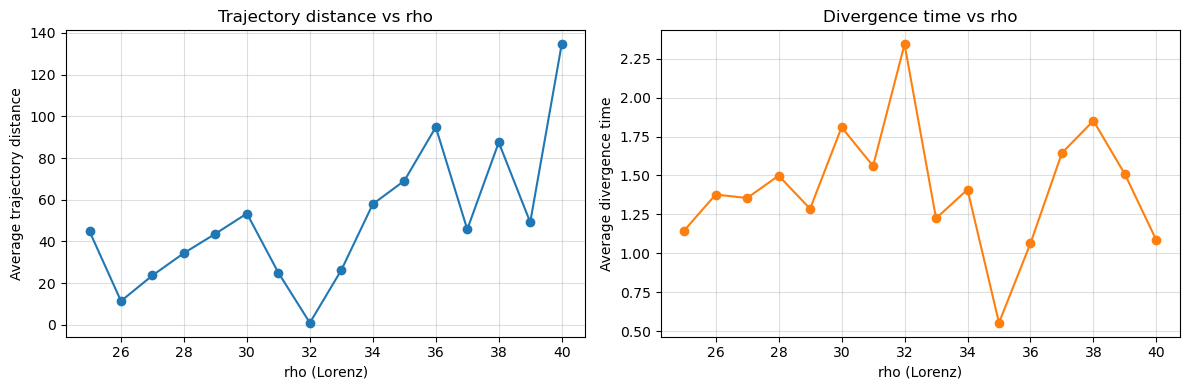

In [33]:
# Plot average trajectory distance vs rho and average divergence time vs rho
import matplotlib.pyplot as plt

rhos = np.array(sweep_summary_rho['rho_values'], dtype=float)
avg_td_r = np.array(sweep_summary_rho['avg_traj_distance'], dtype=float)
avg_dt_r = np.array(sweep_summary_rho['avg_divergence_time'], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rhos, avg_td_r, marker='o')
axes[0].set_xlabel("rho (Lorenz)")
axes[0].set_ylabel("Average trajectory distance")
axes[0].set_title("Trajectory distance vs rho")
axes[0].grid(True, alpha=0.4)

axes[1].plot(rhos, avg_dt_r, marker='o', color='tab:orange')
axes[1].set_xlabel("rho (Lorenz)")
axes[1].set_ylabel("Average divergence time")
axes[1].set_title("Divergence time vs rho")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()